# Where does DP start? The survey pipeline and its invariants

This notebook is the first of five built around
[Drechsler & Bailie (2024), *The Complexities of Differential Privacy for
Survey Data*](https://arxiv.org/abs/2408.07006), a Census-Bureau-funded
study of what goes wrong when DP — designed for a single flat table — meets
a real survey. The paper's running picture is a *survey pipeline*:

```
population -> frame -> sample -> responding sample -> processed data -> outputs
```

A DP mechanism doesn't have to start at the end of this pipeline. It can
begin anywhere, and everything *before* its starting point can either be
left free to vary (part of what DP's neighboring-dataset comparison ranges
over) or fixed as an *invariant*. Both choices change what the resulting
guarantee actually means and how much noise it costs — the same statistic
can need very different amounts of noise depending on where you draw this
line.

This notebook makes that concrete with one running example. The next four
notebooks each dig into one downstream consequence:
[`sampling_amplification.ipynb`](sampling_amplification.ipynb) (does
subsampling earn back privacy budget?),
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)
(what survey weights do to sensitivity),
[`weighting_adjustments.ipynb`](weighting_adjustments.ipynb) (nonresponse
and calibration adjustments), and
[`imputation_and_dp.ipynb`](imputation_and_dp.ipynb) (item nonresponse).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp
from noisyvalue import plot_posterior

## The setup

A frame of `N = 200` people, of whom some fraction have a sensitive binary
attribute `y` (say, a chronic illness). A statistical agency draws an
equal-probability sample of `n = 40` (simple random sampling, so every
sampled person gets the same design weight `w = N / n = 5`) and wants to
release the Horvitz–Thompson estimate of the population total,
`w * sum(y_sample)`.

In [2]:
rng = np.random.default_rng(0)

N, n = 200, 40
w = N / n           # equal-probability design weight
R = 1.0              # y is binary, range 1

y_frame = (rng.random(N) < 0.35).astype(float)
sample_idx = rng.choice(N, size=n, replace=False)
y_sample = y_frame[sample_idx]

true_frame_total = y_frame.sum()
true_ht_total = w * y_sample.sum()
print(f"true frame total:  {true_frame_total:.0f}")
print(f"HT point estimate: {true_ht_total:.1f}")

true frame total:  61
HT point estimate: 65.0


## Three ways to draw the same picture

The paper's Figure 1 traces the pipeline; its Figure 2 shows three concrete
choices of where a DP mechanism could start, and what it takes as invariant
along the way:

- **(a) No invariants, mechanism = last step only.** The standard textbook
  setting: the mechanism takes the *processed data* — here, the 40 sampled
  people's values — as its only input, and says nothing about how that data
  came to be. A "neighboring dataset" is the same 40 people with one
  person's `y` flipped.
- **(b) Frame invariant, mechanism includes sampling.** The population and
  frame are fixed, but the mechanism itself performs the sampling step, so
  DP's neighboring-dataset comparison is made at the *frame* level — the
  200 people, not just the 40 sampled ones.
- **(c) Population and frame invariant, mechanism starts at the responding
  sample.** Almost the same as (a), but explicitly restricted to compare
  only responding samples that *could have come from this frame* — so the
  200-person frame, and hence every sampled person's design weight, is
  common knowledge to both sides of the comparison, not something the
  mechanism itself has to protect.

We'll release the same HT total under each and see what changes.

### (a) Fixed sample of 40 — flip one person's value

If the released mechanism only has to defend against "one of the 40 sampled
values changes," the released quantity is `w * sum(y_sample)`: a sum of 40
terms each bounded in `[0, w*R]`. Its sensitivity under OpenDP's symmetric
distance is exactly `w * R`.

In [3]:
def weighted_sum_release(sensitivity, eps, mechanism="laplace"):
    # Chain a bounded sum with a pure-eps-DP Laplace release (or Gaussian, for rho-DP).
    trans = dp.t.make_sum(
        dp.vector_domain(dp.atom_domain(bounds=(0.0, sensitivity), nan=False)),
        dp.symmetric_distance())
    scale = sensitivity / eps
    make = nvdp.make_laplace if mechanism == "laplace" else nvdp.make_gaussian
    meas = trans >> make(trans.output_domain, trans.output_metric, scale)
    return meas, scale

eps = 1.0
sens_a = w * R
weighted_terms = (w * y_sample).tolist()

meas_a, scale_a = weighted_sum_release(sens_a, eps)
release_a = meas_a(weighted_terms)
print(f"(a) sensitivity: {sens_a:.1f}   Laplace scale: {scale_a:.1f}")
print(f"(a) released HT total: {release_a}")

(a) sensitivity: 5.0   Laplace scale: 5.0
(a) released HT total: ~75.31243858358856


### (c) Frame invariant — the sample itself could have been different

Now the comparison is between responding samples drawn from the *same,
fixed* 200-person frame: instead of "one of the 40 sampled values changes,"
the counterfactual is "the sample includes a different one of the 200 frame
members." Because every frame member shares the same design weight `w`
under equal-probability sampling, substituting any one sampled person for
any other frame member still moves the weighted sum by at most `w * R` —
*numerically the same sensitivity as (a)*.

What's different is the scope of the guarantee, not its size: (a) only
promises to hide which of the 40 *already-sampled* values is which, while
(c) additionally hides sample membership among all 200 frame members, at no
extra noise cost — because the frame (and hence the weights) never had to
be protected in the first place.

In [4]:
sens_c = w * R  # same bound, because weights are homogeneous under SRS
meas_c, scale_c = weighted_sum_release(sens_c, eps)
release_c = meas_c(weighted_terms)
print(f"(c) sensitivity: {sens_c:.1f}   Laplace scale: {scale_c:.1f}  (same as (a))")
print(f"(a) protects substitutions among {n} sampled people")
print(f"(c) protects substitutions among all {N} frame members, for free")

(c) sensitivity: 5.0   Laplace scale: 5.0  (same as (a))
(a) protects substitutions among 40 sampled people
(c) protects substitutions among all 200 frame members, for free


This equivalence is itself a finding of the paper (Section 4): *"for
equal-probability designs all `w_i = N/n` and thus the sensitivity of the
Horvitz–Thompson estimator is the same as for the unweighted estimator."*
It stops holding the moment weights vary across units — see
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb).

### (b) Population invariant only — the mechanism performs the sampling

Here the comparison is at the *frame* level (population fixed, frame free),
but critically the mechanism *includes* the sampling step. A person whose
value differs between two neighboring frames might simply not be drawn into
the sample at all — and if they aren't, the release can't possibly depend on
their value. This is the classical *privacy amplification by subsampling*
result: a mechanism that's `eps`-DP on the sample is only about `r * eps`-DP
at the frame level, where `r = n / N` is the sampling rate.

That gain is the entire subject of
[`sampling_amplification.ipynb`](sampling_amplification.ipynb) — including
why it mostly *disappears* for the multistage, clustered, stratified
designs statistical agencies actually use. Here's just the headline number
for our SRS example, so the three panels of Figure 2 all end up on the same
page:

In [5]:
r = n / N
eps_base = eps  # the "on-the-sample" epsilon from (a)/(c) above

eps_amplified_exact = np.log(1 + r * (np.exp(eps_base) - 1))
eps_amplified_small_eps = r * eps_base

print(f"sampling rate r = n/N:               {r:.2f}")
print(f"epsilon needed without amplification: {eps_base:.2f}")
print(f"epsilon actually spent, with amplification (exact bound):     {eps_amplified_exact:.3f}")
print(f"epsilon actually spent, with amplification (small-eps approx r*eps): {eps_amplified_small_eps:.3f}")

sampling rate r = n/N:               0.20
epsilon needed without amplification: 1.00
epsilon actually spent, with amplification (exact bound):     0.295
epsilon actually spent, with amplification (small-eps approx r*eps): 0.200


Fixing the frame (b) started free — DP releasing over the whole
sampling-and-noising pipeline is, for this simple design, roughly *five
times* more private per unit of noise than either (a) or (c). We'll spend
the next notebook checking exactly how much of that bonus survives contact
with a real, multistage survey design.

## Visualizing the trade-off

All three releases above used `eps=1` against different neighbor
definitions, so they aren't directly comparable as noise magnitudes — (a)
and (c) used the *same* scale, and (b)'s bonus is a statement about what
`eps` on the *sample* buys you at the *frame* level, not a smaller Laplace
scale. To see the trade-off as noise, we hold the *frame-level* privacy loss
fixed at `eps_frame = 1` and ask how much sample-level noise buys us that
guarantee with and without amplification:

no amplification: sample-level noise scale = 5.00
with amplification: sample-level noise scale = 2.21
amplification lets us use 2.3x less noise for the same frame-level guarantee


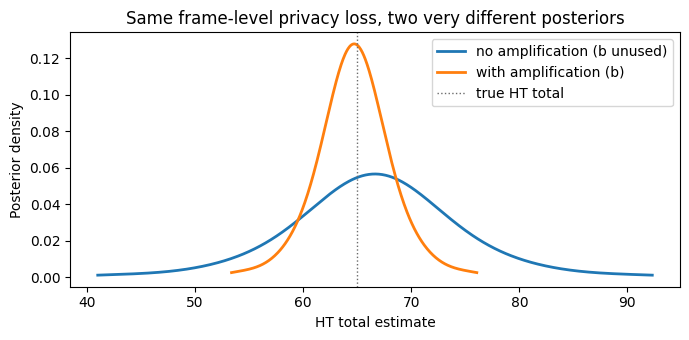

In [6]:
eps_frame = 1.0

# without amplification: the mechanism must be eps_frame-DP on the sample directly
meas_no_amp, scale_no_amp = weighted_sum_release(sens_a, eps_frame)
value_no_amp = meas_no_amp(weighted_terms)

# with amplification: eps_frame = ln(1 + r*(exp(eps_sample) - 1)) solved for eps_sample
eps_sample_with_amp = np.log(1 + (np.exp(eps_frame) - 1) / r)
meas_with_amp, scale_with_amp = weighted_sum_release(sens_a, eps_sample_with_amp)
value_with_amp = meas_with_amp(weighted_terms)

print(f"no amplification: sample-level noise scale = {scale_no_amp:.2f}")
print(f"with amplification: sample-level noise scale = {scale_with_amp:.2f}")
print(f"amplification lets us use {scale_no_amp / scale_with_amp:.1f}x less noise "
      f"for the same frame-level guarantee")

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_posterior(value_no_amp, value_with_amp, ax=ax)
ax.axvline(true_ht_total, color="#6b6b6b", linewidth=1, linestyle=":", label="true HT total")
ax.legend(["no amplification (b unused)", "with amplification (b)", "true HT total"])
ax.set_title("Same frame-level privacy loss, two very different posteriors")
ax.set_xlabel("HT total estimate")
plt.tight_layout()

## What this notebook did *not* need

Notice that using the pipeline framing didn't require any new machinery —
`nvdp.make_gaussian`/`make_laplace` already chain onto whatever OpenDP
transformation computes the statistic, so "what counts as the mechanism"
and "what counts as an invariant" are just choices about which
transformation you chain and which sensitivity you declare, not something
the library needs to know about explicitly. What *is* new here is purely
conceptual: the same code, run with a different mental model of what the
mechanism's input is, gives a meaningfully different — and in case (b),
much cheaper — privacy guarantee.